In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')
zip_path = '/content/drive/MyDrive/Plants Diseases Detection and Classification.v3i.coco.zip'
extract_path = '/content/dataset3'

if not os.path.exists(extract_path):
    os.makedirs(extract_path)
    !unzip -q "{zip_path}" -d "{extract_path}"
    print("Giải nén thành công!")
else:
    print("Dữ liệu đã được giải nén.")
    /// Giải nén
    

Mounted at /content/drive
Giải nén thành công!


In [2]:
!pip install -q torchmetrics
!pip install -q pycocotools
import seaborn as sns
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn
from torch.utils.data import DataLoader
from torchvision import transforms as T
import torchvision.transforms.functional as F
from pycocotools.coco import COCO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os
import csv
from torchmetrics.detection.mean_ap import MeanAveragePrecision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.3 MB/s eta 0:00:00


In [8]:

class CustomCOCODataset(torch.utils.data.Dataset):
    def __init__(self, root, annotation, transforms=None):
        self.root, self.transforms = root, transforms
        self.coco = COCO(annotation)
        self.ids = list(sorted(self.coco.imgs.keys()))
        # Map category_id về 1, 2, 3...
        self.cat_map = {old: new for new, old in enumerate(sorted(self.coco.getCatIds()), 1)}

    def __getitem__(self, index):
        img_id = self.ids[index]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        img = Image.open(os.path.join(self.root, self.coco.loadImgs(img_id)[0]['file_name'])).convert('RGB')
        boxes, labels = [], []
        for ann in anns:
            x, y, w, h = ann['bbox']
            if w > 0 and h > 0:
                boxes.append([x, y, x + w, y + h])
                labels.append(self.cat_map[ann['category_id']])
        target = {
            "boxes": torch.as_tensor(boxes or torch.empty((0, 4)), dtype=torch.float32),
            "labels": torch.as_tensor(labels or torch.empty((0,), dtype=torch.int64)),
            "image_id": torch.tensor([img_id]),
            "area": torch.as_tensor([a[2]*a[3] for a in [ann['bbox'] for ann in anns] if a[2]>0 and a[3]>0] or [], dtype=torch.float32),
            "iscrowd": torch.zeros(len(labels), dtype=torch.int64)
        }

        if self.transforms: img, target = self.transforms(img, target)
        return img, target
    def __len__(self): return len(self.ids)
def get_model_object_detection(num_classes):
    # Sử dụng MobileNetV3 làm backbone để train nhanh
    model = fasterrcnn_mobilenet_v3_large_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # Thay thế head bằng số lớp của bạn
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model
# Hàm bổ trợ rút gọn
collate_fn = lambda batch: tuple(zip(*batch))

In [9]:
# Cấu hình đường dẫn
path = '/content/dataset3'
data_cfg = {'train': (f'{path}/train', f'{path}/train/_annotations.coco.json'),
            'valid': (f'{path}/valid', f'{path}/valid/_annotations.coco.json')}
def get_transform():
    from torchvision.transforms import functional as F
    return lambda img, target: (F.to_tensor(img), target)
# Khởi tạo Datasets & Loaders
train_ds = CustomCOCODataset(*data_cfg['train'], get_transform())
valid_ds = CustomCOCODataset(*data_cfg['valid'], get_transform())

NUM_CLASSES = len(train_ds.cat_map) + 1
print(f"Số lớp bao gồm background: {NUM_CLASSES}")

train_loader = DataLoader(train_ds, 8, shuffle=True, num_workers=2, collate_fn=collate_fn)
valid_loader = DataLoader(valid_ds, 4, shuffle=False, num_workers=2, collate_fn=collate_fn)

# Khởi tạo model & optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = get_model_object_detection(NUM_CLASSES).to(device)
optimizer = torch.optim.SGD(model.parameters(), 0.005, 0.9, weight_decay=0.0005)

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Số lớp bao gồm background: 31


In [10]:
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for i, (images, targets) in enumerate(train_loader):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        epoch_loss += losses.item()

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        if i % 50 == 0:
            print(f"Epoch {epoch+1} | Batch {i} | Loss: {losses.item():.4f}")

    print(f"--- Kết thúc Epoch {epoch+1} | Total Loss: {epoch_loss:.4f} ---")

Epoch 1 | Batch 0 | Loss: 4.3803


KeyboardInterrupt: 

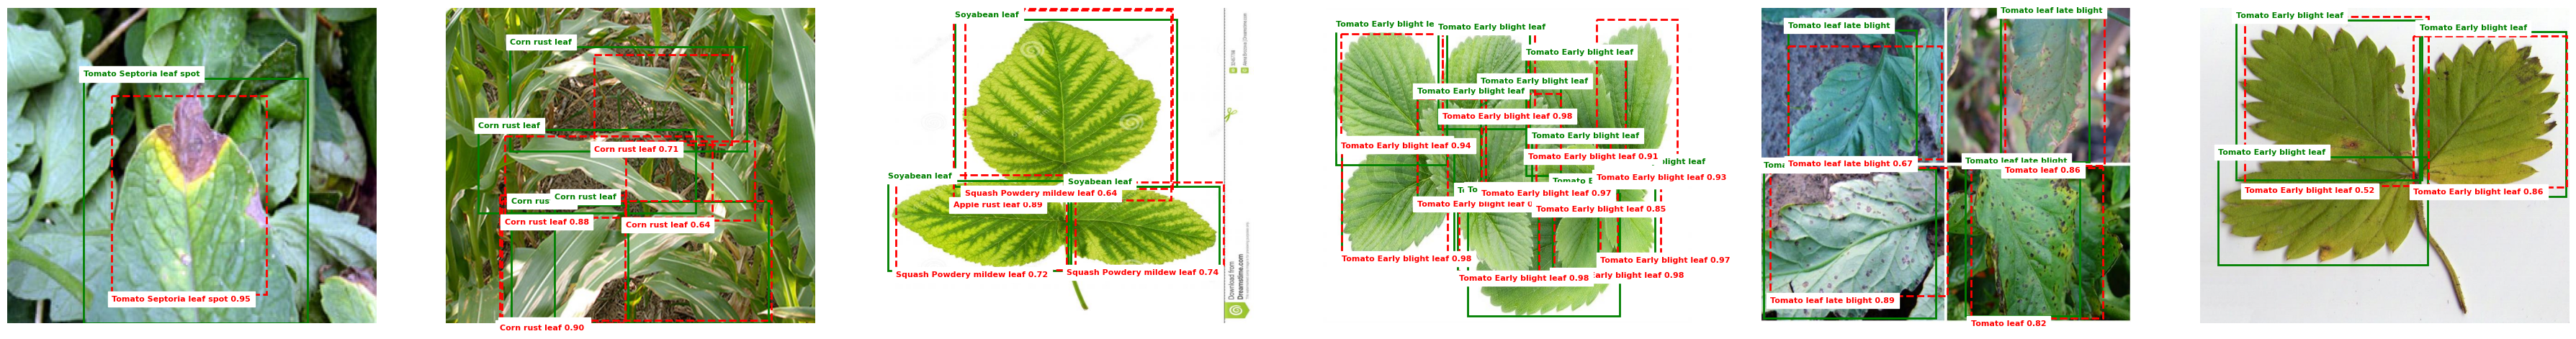

In [ ]:

# 1. Lấy tất cả categories từ coco
coco_cats = train_ds.coco.cats
# 2. Tìm ID lớn nhất để xác định độ dài mảng
max_id = max(coco_cats.keys())
# 3. Tạo list với giá trị mặc định là "Unknown"
CLASS_NAMES = ["Background"] + ["Unknown"] * max_id
# 4. Gán tên vào đúng vị trí ID
for cat_id, cat_info in coco_cats.items():
    CLASS_NAMES[cat_id] = cat_info['name']
def visualize_predictions(model, dataset, class_names, num_images=6):
    model.eval()
    fig, axes = plt.subplots(1, num_images, figsize=(6 * num_images, 6))
    if num_images == 1: axes = [axes]
    with torch.no_grad():
        for i in range(num_images):
            img, target = dataset[i]
            pred = model([img.to(device)])[0]
            axes[i].imshow(img.permute(1, 2, 0).cpu().numpy())
            axes[i].axis('off')
            # Hàm phụ trợ để lấy tên an toàn
            def get_name(idx):
                idx = idx.item()
                return class_names[idx] if idx < len(class_names) else f"ID {idx}"
            # Vẽ Ground Truth (Xanh)
            for box, lbl in zip(target['boxes'], target['labels']):
                x, y, xmax, ymax = box.cpu().numpy()
                axes[i].add_patch(patches.Rectangle((x, y), xmax-x, ymax-y, lw=2, ec='g', fc='none'))
                axes[i].text(x, y-5, get_name(lbl), color='g', fontsize=8, backgroundcolor="white", weight='bold')
            # Vẽ Predictions (Đỏ) - Chỉ lấy score > 0.5
            keep = pred['scores'] > 0.5
            for box, score, lbl in zip(pred['boxes'][keep], pred['scores'][keep], pred['labels'][keep]):
                x, y, xmax, ymax = box.cpu().numpy()
                axes[i].add_patch(patches.Rectangle((x, y), xmax-x, ymax-y, lw=2, ec='r', fc='none', linestyle='--'))
                axes[i].text(x, ymax+15, f"{get_name(lbl)} {score:.2f}", color='r', fontsize=8, backgroundcolor="white", weight='bold')
    plt.tight_layout()
    plt.show()
# Gọi hàm
visualize_predictions(model, valid_ds, CLASS_NAMES, num_images=6)

Đang phân tích để vẽ biểu đồ...


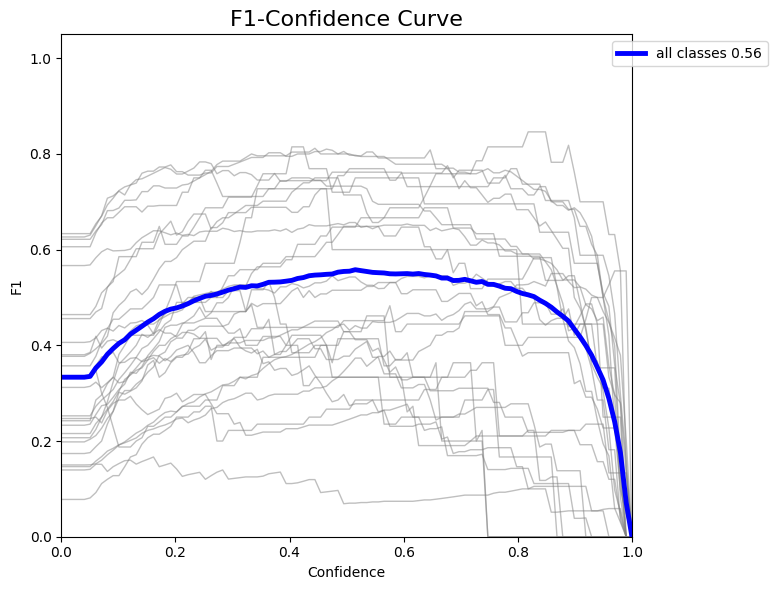

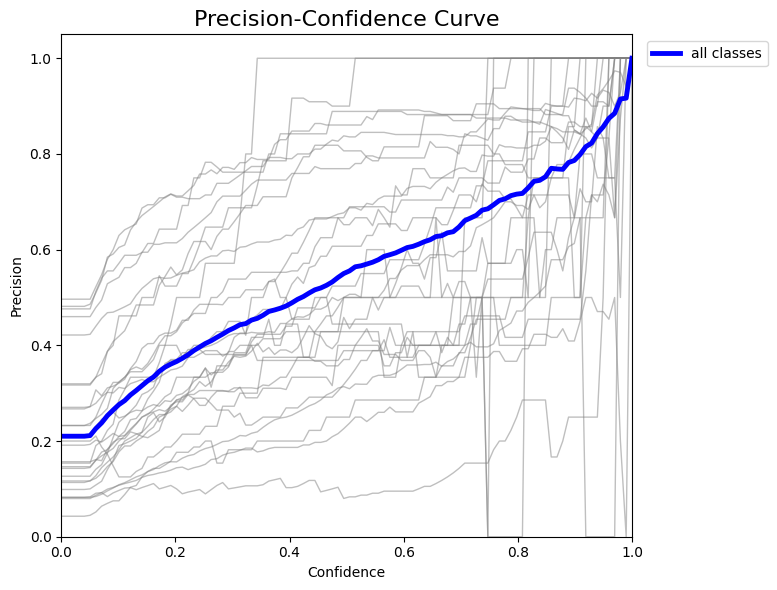

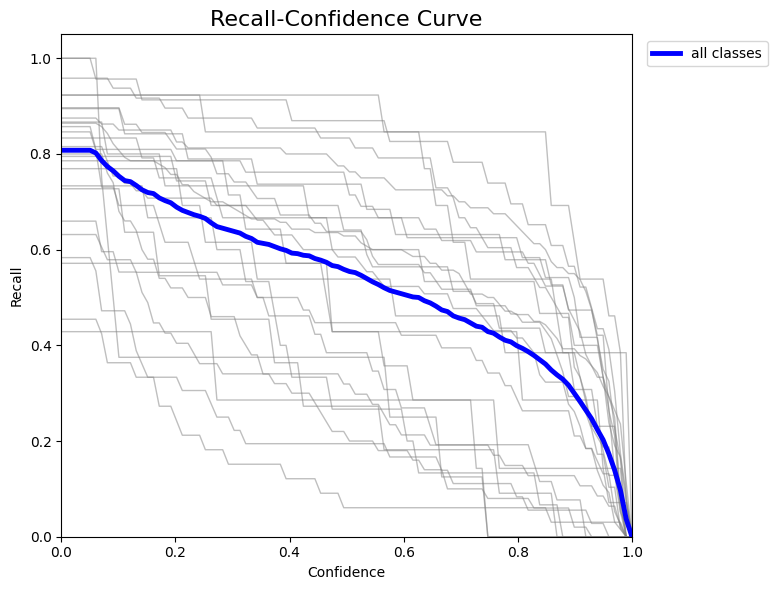

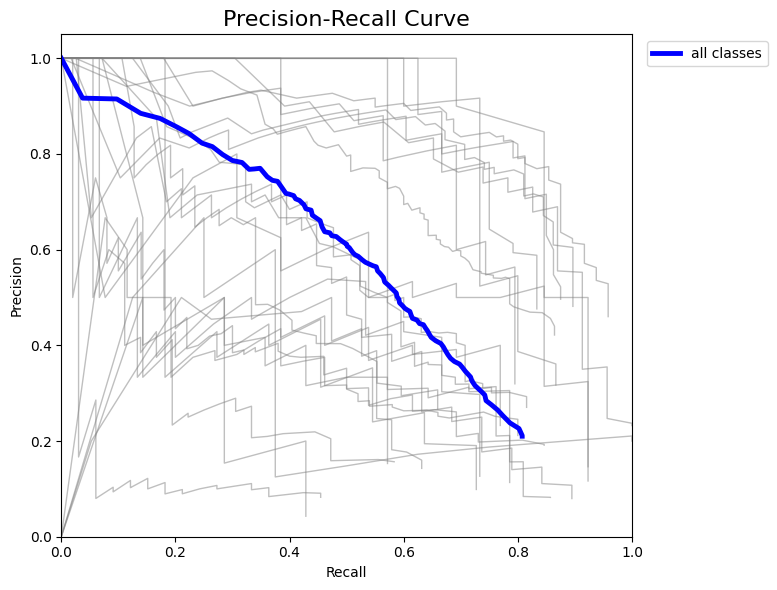

In [ ]:
def generate_multi_class_yolo_curves(model, data_loader, num_classes, run_dir, iou_thresh=0.5):
    print("Đang phân tích để vẽ biểu đồ...")
    model.eval()

    all_scores, all_tps, all_fps, all_pred_classes = [], [], [], []
    total_gts_per_class = {c: 0 for c in range(1, num_classes)}
    total_gts = 0

    with torch.no_grad():
        for images, targets in data_loader:
            preds = model(list(img.to(device) for img in images))
            for pred, target in zip(preds, targets):
                gt_boxes, gt_labels = target['boxes'].cpu(), target['labels'].cpu().numpy()
                for lbl in gt_labels: total_gts_per_class[lbl] += 1; total_gts += 1

                p_boxes, p_scores, p_labels = pred['boxes'].cpu(), pred['scores'].cpu().numpy(), pred['labels'].cpu().numpy()
                if len(p_scores) == 0: continue

                # Sắp xếp confidence từ cao xuống thấp
                sort_idx = np.argsort(-p_scores)
                p_boxes, p_scores, p_labels = p_boxes[sort_idx], p_scores[sort_idx], p_labels[sort_idx]
                detected_gt = set()

                for p_box, p_lbl, p_score in zip(p_boxes, p_labels, p_scores):
                    is_tp, is_fp = 0, 1
                    if len(gt_boxes) > 0:
                        ious = box_iou(p_box.unsqueeze(0), gt_boxes).numpy()[0]
                        # Tìm GT box khớp có IoU cao nhất
                        valid_gts = [(i, iou) for i, iou in enumerate(ious) if iou >= iou_thresh and i not in detected_gt and gt_labels[i] == p_lbl]
                        if valid_gts:
                            best_g_idx = max(valid_gts, key=lambda x: x[1])[0]
                            is_tp, is_fp = 1, 0
                            detected_gt.add(best_g_idx)

                    all_scores.append(p_score); all_tps.append(is_tp); all_fps.append(is_fp); all_pred_classes.append(p_lbl)

    # Chuyển đổi sang numpy
    all_scores, all_tps, all_fps, all_pred_classes = map(np.array, [all_scores, all_tps, all_fps, all_pred_classes])
    thresholds = np.linspace(0.0, 1.0, 100)

    # --- HÀM TÍNH P, R, F1 CHUNG (Đã fix lỗi cắm đầu) ---
    def calc_metrics(scores, tps, fps, total_gt):
        p_cv, r_cv, f1_cv = [], [], []
        for t in thresholds:
            mask = scores >= t
            tp_sum, fp_sum = np.sum(tps[mask]), np.sum(fps[mask])

            p = 1.0 if (tp_sum + fp_sum) == 0 else tp_sum / (tp_sum + fp_sum) # Fix lỗi đường cắm xuống 0
            r = tp_sum / (total_gt + 1e-6)
            f1 = 0.0 if (p + r) == 0 else 2 * p * r / (p + r)

            p_cv.append(p); r_cv.append(r); f1_cv.append(f1)
        return np.array(p_cv), np.array(r_cv), np.array(f1_cv)

    # 1 & 2. Tính toán cho từng class và tổng hợp
    class_metrics = {c: calc_metrics(all_scores[all_pred_classes == c], all_tps[all_pred_classes == c], all_fps[all_pred_classes == c], total_gts_per_class[c])
                     for c in range(1, num_classes) if total_gts_per_class[c] > 0}
    g_p, g_r, g_f1 = calc_metrics(all_scores, all_tps, all_fps, total_gts)

    # --- HÀM VẼ GỘP CHUNG (Xử lý cả 4 loại biểu đồ) ---
    def plot_curve(x_idx, y_idx, xlabel, ylabel, title, filename):
        plt.figure(figsize=(8, 6))
        for metrics in class_metrics.values():
            x_data = metrics[1] if x_idx == 1 else thresholds # 1 là chỉ số của array Recall
            plt.plot(x_data, metrics[y_idx], color='gray', lw=1, alpha=0.5)

        x_g = g_r if x_idx == 1 else thresholds
        lbl = f'all classes {np.max(g_f1):.2f}' if y_idx == 2 else 'all classes'
        plt.plot(x_g, [g_p, g_r, g_f1][y_idx], color='blue', lw=3.5, label=lbl)

        plt.title(title, fontsize=16); plt.xlabel(xlabel); plt.ylabel(ylabel)
        plt.xlim(0, 1); plt.ylim(0, 1.05); plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
        plt.tight_layout(); plt.savefig(os.path.join(run_dir, filename), dpi=300); plt.show()

    # VẼ VÀ LƯU 4 BIỂU ĐỒ (Chỉ mục y_idx: 0=P, 1=R, 2=F1)
    plot_curve(0, 2, 'Confidence', 'F1', 'F1-Confidence Curve', 'BoxF1_curve.png')
    plot_curve(0, 0, 'Confidence', 'Precision', 'Precision-Confidence Curve', 'BoxP_curve.png')
    plot_curve(0, 1, 'Confidence', 'Recall', 'Recall-Confidence Curve', 'BoxR_curve.png')
    plot_curve(1, 0, 'Recall', 'Precision', 'Precision-Recall Curve', 'BoxPR_curve.png')

# Chạy
generate_multi_class_yolo_curves(model, valid_loader, NUM_CLASSES, RUN_DIR)

In [3]:

from torchvision.ops import box_iou
def plot_confusion_matrix_detection(model, data_loader, num_classes, run_dir, iou_thresh=0.5, score_thresh=0.5):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    model.eval()
    with torch.no_grad():
        for images, targets in data_loader:
            preds = model(list(img.to(device) for img in images))
            for pred, target in zip(preds, targets):
                gt_boxes, gt_labels = target['boxes'].cpu(), target['labels'].cpu().numpy()
                # Lọc threshold và chuyển tensor -> numpy trong 1 dòng
                keep = pred['scores'] > score_thresh
                p_boxes, p_labels = pred['boxes'][keep].cpu(), pred['labels'][keep].cpu().numpy()
                if len(gt_boxes) == 0 and len(p_boxes) == 0: continue
                # Tính IoU
                ious = box_iou(gt_boxes, p_boxes).numpy() if len(gt_boxes) and len(p_boxes) else np.zeros((0,0))
                matched_gt, matched_p = set(), set()
                # Tìm các cặp khớp (Matches)
                if ious.size > 0:
                    matches = sorted(np.argwhere(ious >= iou_thresh), key=lambda x: ious[x[0], x[1]], reverse=True)
                    for g_idx, p_idx in matches:
                        if g_idx not in matched_gt and p_idx not in matched_p:
                            matched_gt.add(g_idx)
                            matched_p.add(p_idx)
                            cm[gt_labels[g_idx], p_labels[p_idx]] += 1
                # Ghi nhận False Negatives (Bỏ sót -> Background)
                for i, g_lbl in enumerate(gt_labels):
                    if i not in matched_gt: cm[g_lbl, 0] += 1
                # Ghi nhận False Positives (Đoán thừa -> Nền thành Class)
                for j, p_lbl in enumerate(p_labels):
                    if j not in matched_p: cm[0, p_lbl] += 1
    # --- VẼ VÀ ƯU BIỂU ĐỒ ---
    plt.figure(figsize=(12, 10))
    labels = ["Background"] + [f"Class {i}" for i in range(1, num_classes)]
    cm_ratio = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-6)
    sns.heatmap(cm_ratio, annot=True, fmt=".2f", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title("Confusion Matrix - Faster R-CNN", fontsize=16)
    plt.ylabel("Thực tế (Ground Truth)"); plt.xlabel("Dự đoán (Predicted)")
    plt.xticks(rotation=45, ha='right'); plt.tight_layout()
    # Lưu gộp 2 file cực nhanh
    for name in ['confusion_matrix_normalized.png', 'confusion_matrix.png']:
        plt.savefig(os.path.join(run_dir, name), dpi=300)
    plt.show()
    print(f"✓ Đã lưu ma trận nhầm lẫn vào: {run_dir}")

# Gọi hàm thực thi
RUN_DIR = '/content/dataset3/run'
plot_confusion_matrix_detection(model, valid_loader, NUM_CLASSES, RUN_DIR)



NameError: name 'model' is not defined

In [ ]:
!zip -r /content/run_results.zip /content/dataset3/run
from google.colab import files
files.download('/content/run_results.zip')

  adding: content/dataset3/run/ (stored 0%)
  adding: content/dataset3/run/results.csv (deflated 55%)
  adding: content/dataset3/run/BoxP_curve.png (deflated 7%)
  adding: content/dataset3/run/weights/ (stored 0%)
  adding: content/dataset3/run/weights/last.pt (deflated 7%)
  adding: content/dataset3/run/BoxPR_curve.png (deflated 10%)
  adding: content/dataset3/run/BoxR_curve.png (deflated 8%)
  adding: content/dataset3/run/BoxF1_curve.png (deflated 8%)
  adding: content/dataset3/run/.ipynb_checkpoints/ (stored 0%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>